In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
df=pd.read_csv('/content/train.csv',usecols=['Survived','Age','Fare'])
df.head()
df.shape

(891, 3)

In [8]:
df.dropna(inplace =True)

In [9]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [10]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [12]:
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6363636363636364

In [13]:
np.mean(cross_val_score(clf,X,y,cv=10,scoring='accuracy'))

np.float64(0.6317292644757433)

In [14]:
kbin_age=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [15]:
trf=ColumnTransformer([('first',kbin_age,[0]),('Second',kbin_fare,[1])],remainder='passthrough')

In [16]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

In [17]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [18]:
trf.named_transformers_['Second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [20]:
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred2=clf.predict(X_test)
accuracy_score(y_test,y_pred2)

0.6293706293706294

In [31]:
np.mean(cross_val_score(clf,X,y,cv=10,scoring='accuracy'))

np.float64(0.6387128325508608)

In [48]:
def discretizer(bins,strategy):
    kbin_age=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    X_trf=trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,5))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")



    plt.figure(figsize=(14,4))
    plt.subplot(221)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(222)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()


0.6288928012519561


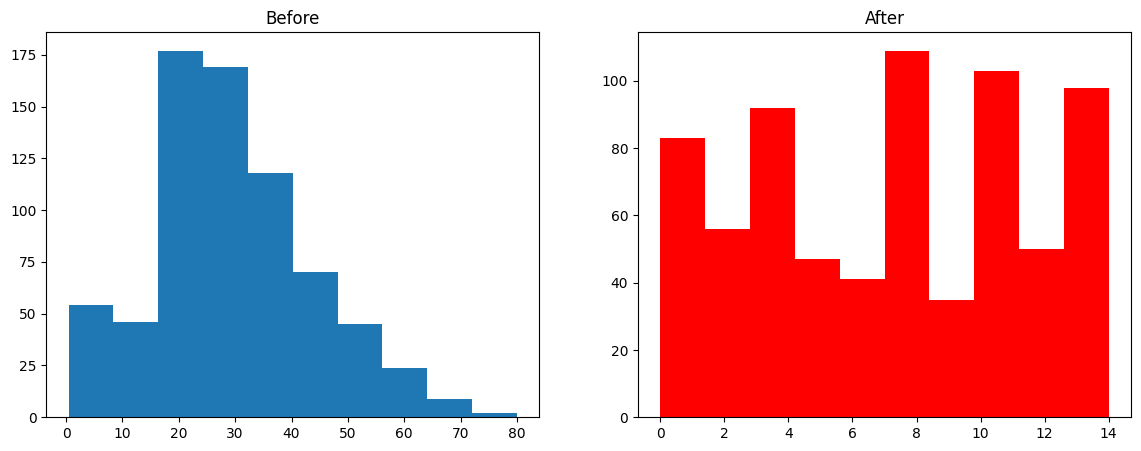

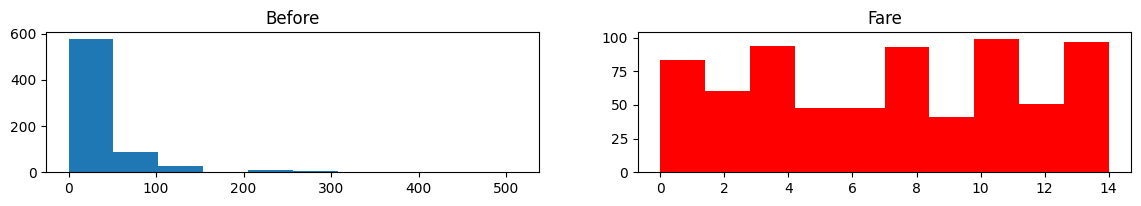

In [49]:
discretizer(15,'quantile')